# Exploratory Data Analysis - BoardGames Dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.feature_extraction.text import TfidfVectorizer

## Databases

We have two datasets with info, so we will check the initial columns, combine them and then clean them

In [3]:
ranking = pd.read_csv("../data/raw/2026-03-05.csv")
details = pd.read_csv("../data/raw/games_detailed_info2025.csv")

In [4]:
ranking.head()

,ID,Name,Year,Rank,Average,Bayes average,Users rated,URL,Thumbnail
0,224517,Brass: Birmingham,2018,1,8.57,8.395,57100,/boardgame/224517/brass-birmingham,https://cf.geekdo-images.com/x3zxjr-Vw5iU4yDPg...
1,342942,Ark Nova,2021,2,8.54,8.355,59476,/boardgame/342942/ark-nova,https://cf.geekdo-images.com/SoU8p28Sk1s8MSvoM...
2,161936,Pandemic Legacy: Season 1,2015,3,8.50,8.348,57097,/boardgame/161936/pandemic-legacy-season-1,https://cf.geekdo-images.com/-Qer2BBPG7qGGDu6K...
3,174430,Gloomhaven,2017,4,8.54,8.303,66722,/boardgame/174430/gloomhaven,https://cf.geekdo-images.com/sZYp_3BTDGjh2unaZ...
4,316554,Dune: Imperium,2020,5,8.41,8.224,57343,/boardgame/316554/dune-imperium,https://cf.geekdo-images.com/PhjygpWSo-0labGrP...


In [5]:
print(f"Database shape : {ranking.shape}\n")
ranking.info()

Database shape : (30224, 9)

<class 'pandas.DataFrame'>
RangeIndex: 30224 entries, 0 to 30223
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             30224 non-null  int64  
 1   Name           30224 non-null  str    
 2   Year           30224 non-null  int64  
 3   Rank           30224 non-null  int64  
 4   Average        30224 non-null  float64
 5   Bayes average  30224 non-null  float64
 6   Users rated    30224 non-null  int64  
 7   URL            30224 non-null  str    
 8   Thumbnail      30220 non-null  str    
dtypes: float64(2), int64(4), str(3)
memory usage: 2.1 MB


In [6]:
details.head()

,Unnamed: 0,type,id,thumbnail,image,alternate,description,yearpublished,minplayers,maxplayers,...,boardgameintegration,Abstract Game Rank,Party Game Rank,Thematic Rank,War Game Rank,Customizable Rank,Children's Game Rank,RPG Item Rank,Accessory Rank,name
0,0,boardgame,13,https://cf.geekdo-images.com/PyUol9QxBnZQCJqZI...,https://cf.geekdo-images.com/PyUol9QxBnZQCJqZI...,"['Catan', 'Catan (Колонизаторы)', 'Catan telep...","In CATAN (formerly The Settlers of Catan), pla...",1995,3,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CATAN
1,1,boardgame,822,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...,https://cf.geekdo-images.com/okM0dq_bEXnbyQTOv...,"['Carcassonne Jubilee Edition', 'Carcassonne: ...",Carcassonne is a tile placement game in which ...,2000,2,5,...,"['Carcassonne: Wheel of Fortune', 'Mists over ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Carcassonne
2,2,boardgame,30549,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...,https://cf.geekdo-images.com/S3ybV1LAp-8SnHIXL...,"['EPIZOotic', 'Pandemia', 'Pandemia 10 Anivers...","In Pandemic, several virulent diseases have br...",2008,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pandemic
3,3,boardgame,68448,https://cf.geekdo-images.com/35h9Za_JvMMMtx_92...,https://cf.geekdo-images.com/35h9Za_JvMMMtx_92...,"['7 csoda', '7 Cudów Świata', '7 divů světa', ...",You are the leader of one of the 7 great citie...,2010,2,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7 Wonders
4,4,boardgame,167791,https://cf.geekdo-images.com/wg9oOLcsKvDesSUdZ...,https://cf.geekdo-images.com/wg9oOLcsKvDesSUdZ...,"['A Mars terraformálása', 'Mars: Teraformace',...","In the 2400s, mankind begins to terraform the ...",2016,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terraforming Mars


In [7]:
print(f"Database shape : {details.shape}\n")
details.info()

Database shape : (27780, 52)

<class 'pandas.DataFrame'>
RangeIndex: 27780 entries, 0 to 27779
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     27780 non-null  int64  
 1   type                           27780 non-null  str    
 2   id                             27780 non-null  int64  
 3   thumbnail                      27764 non-null  str    
 4   image                          27761 non-null  str    
 5   alternate                      11508 non-null  str    
 6   description                    27779 non-null  str    
 7   yearpublished                  27780 non-null  int64  
 8   minplayers                     27780 non-null  int64  
 9   maxplayers                     27780 non-null  int64  
 10  suggested_num_players          27780 non-null  str    
 11  suggested_playerage            27777 non-null  str    
 12  suggested_language_dependen

### Start with the combination

In [8]:
ranking.columns = [columns.lower().replace(" ", "_") for columns in ranking.columns]
ranking = ranking.rename(columns={"average":"average_rating"})

In [9]:
combined = pd.merge(ranking, details, on='id', how='inner')

In [10]:
combined.columns

Index(['id', 'name_x', 'year', 'rank', 'average_rating', 'bayes_average',
       'users_rated', 'url', 'thumbnail_x', 'Unnamed: 0', 'type',
       'thumbnail_y', 'image', 'alternate', 'description', 'yearpublished',
       'minplayers', 'maxplayers', 'suggested_num_players',
       'suggested_playerage', 'suggested_language_dependence', 'playingtime',
       'minplaytime', 'maxplaytime', 'minage', 'boardgamecategory',
       'boardgamemechanic', 'boardgamefamily', 'boardgameexpansion',
       'boardgameaccessory', 'boardgamecompilation', 'boardgameimplementation',
       'boardgamedesigner', 'boardgameartist', 'boardgamepublisher',
       'usersrated', 'average', 'bayesaverage', 'Board Game Rank',
       'Strategy Game Rank', 'Family Game Rank', 'stddev', 'median', 'owned',
       'trading', 'wanting', 'wishing', 'numcomments', 'numweights',
       'averageweight', 'boardgameintegration', 'Abstract Game Rank',
       'Party Game Rank', 'Thematic Rank', 'War Game Rank',
       'Customiz

In [11]:
combined = combined.rename(columns={"name_x": "name", "usersrated_x": "users_rated"})

In [12]:
#Determine the columns to use. Keeping the most updated ones in the case of a duplication after merging
columns_keep = [

# identifier
"id",
"name",

# target
"average_rating",

# gameplay
"yearpublished",
"minplayers",
"maxplayers",
"playingtime",
"minplaytime",
"maxplaytime",
"minage",

# complexity
"averageweight",

# popularity
"users_rated",
"owned",
"wishing",

# ranking
"rank",

# categories
"boardgamecategory",
"boardgamemechanic"
]

combined = combined[columns_keep]

In [13]:
combined.head()

,id,name,average_rating,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,averageweight,users_rated,owned,wishing,rank,boardgamecategory,boardgamemechanic
0,224517,Brass: Birmingham,8.57,2018,2,4,120,60,120,14,3.8703,57100,70860,19358,1,"['Age of Reason', 'Economic', 'Industry / Manu...","['Hand Management', 'Income', 'Loans', 'Market..."
1,342942,Ark Nova,8.54,2021,1,4,150,90,150,14,3.7752,59476,72761,14899,2,"['Animals', 'Economic', 'Environmental']","['Action Queue', 'End Game Bonuses', 'Grid Cov..."
2,161936,Pandemic Legacy: Season 1,8.50,2015,2,4,60,60,60,13,2.8295,57097,85777,14189,3,"['Environmental', 'Medical']","['Action Points', 'Cooperative Game', 'Hand Ma..."
3,174430,Gloomhaven,8.54,2017,1,4,120,60,120,14,3.9125,66722,99872,21160,4,"['Adventure', 'Exploration', 'Fantasy', 'Fight...","['Action Queue', 'Action Retrieval', 'Campaign..."
4,316554,Dune: Imperium,8.41,2020,1,4,120,60,120,14,3.0592,57343,68614,14213,5,"['Movies / TV / Radio theme', 'Novel-based', '...","['Card Play Conflict Resolution', 'Deck, Bag, ..."


In [14]:
print(f"Database shape : {combined.shape}\n")
combined.info()

Database shape : (27736, 17)

<class 'pandas.DataFrame'>
RangeIndex: 27736 entries, 0 to 27735
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 27736 non-null  int64  
 1   name               27736 non-null  str    
 2   average_rating     27736 non-null  float64
 3   yearpublished      27736 non-null  int64  
 4   minplayers         27736 non-null  int64  
 5   maxplayers         27736 non-null  int64  
 6   playingtime        27736 non-null  int64  
 7   minplaytime        27736 non-null  int64  
 8   maxplaytime        27736 non-null  int64  
 9   minage             27736 non-null  int64  
 10  averageweight      27736 non-null  float64
 11  users_rated        27736 non-null  int64  
 12  owned              27736 non-null  int64  
 13  wishing            27736 non-null  int64  
 14  rank               27736 non-null  int64  
 15  boardgamecategory  27364 non-null  str    
 16  boa

### Cleaning of the database

Checking null values

In [15]:
combined.isna().sum()

id                      0
name                    0
average_rating          0
yearpublished           0
minplayers              0
maxplayers              0
playingtime             0
minplaytime             0
maxplaytime             0
minage                  0
averageweight           0
users_rated             0
owned                   0
wishing                 0
rank                    0
boardgamecategory     372
boardgamemechanic    1758
dtype: int64

In [16]:
combined['boardgamecategory'] = combined['boardgamecategory'].fillna('[]')
combined['boardgamemechanic'] = combined['boardgamemechanic'].fillna('[]')

Removing duplicates

In [17]:
combined.duplicated().sum()  

np.int64(7)

In [18]:
combined[combined.duplicated()]  

,id,name,average_rating,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,averageweight,users_rated,owned,wishing,rank,boardgamecategory,boardgamemechanic
1879,1829,Risk 2210 A.D.,6.69,2001,2,5,240,240,240,10,2.7190,7348,13149,575,1900,"['Science Fiction', 'Territory Building', 'War...","['Area Majority / Influence', 'Area Movement',..."
1880,235555,Bios: Origins (Second Edition),7.73,2019,1,4,240,120,240,14,4.1765,1326,3570,1062,1897,"['Civilization', 'Environmental', 'Exploration...","['Area Majority / Influence', 'Auction: Once A..."
27712,3510,Battle of the Sexes,3.50,1997,2,8,45,45,45,12,1.0759,1180,2287,18,30201,"['Party Game', 'Trivia']",['Team-Based Game']
27713,2785,Game of Goose,3.52,1587,2,6,20,20,20,5,1.0568,1141,1458,36,30202,"['Animals', ""Children's Game"", 'Educational', ...","['Dice Rolling', 'Events', 'Lose a Turn', 'Rac..."
27714,6424,Pick Up Sticks,4.38,1850,2,6,30,10,30,4,1.0485,3121,4227,49,30203,"['Action / Dexterity', ""Children's Game"", 'Par...","['Physical Removal', 'Push Your Luck', 'Set Co..."
27715,4378,Cootie,3.44,1927,2,4,20,20,20,3,1.0227,1109,1619,23,30204,"['Animals', ""Children's Game"", 'Dice']","['Dice Rolling', 'Paper-and-Pencil', 'Set Coll..."
27716,2425,Battleship,4.75,1931,2,2,30,30,30,8,1.2036,12107,19357,180,30205,"[""Children's Game"", 'Nautical']","['Deduction', 'Paper-and-Pencil', 'Secret Unit..."


In [19]:
combined = combined.drop_duplicates()

Getting more detailed info

In [20]:
combined.describe()

,id,average_rating,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,averageweight,users_rated,owned,wishing,rank
count,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000,27729.000000
mean,160236.766490,6.448772,1989.499513,1.960799,5.942299,91.747701,56.948393,91.747701,9.677882,1.940898,1029.777525,1693.220347,263.766382,14874.140575
std,132157.656621,0.909938,203.441498,0.707932,13.741209,696.176614,380.479117,696.176614,3.652670,0.833529,4491.197176,6460.258091,927.629311,8866.012511
min,1.000000,1.260000,-3500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,1.000000
25%,20595.000000,5.890000,2004.000000,2.000000,4.000000,25.000000,20.000000,25.000000,8.000000,1.250000,62.000000,155.000000,16.000000,7134.000000
50%,156843.000000,6.490000,2014.000000,2.000000,4.000000,45.000000,30.000000,45.000000,10.000000,1.865600,141.000000,340.000000,44.000000,14552.000000
75%,270443.000000,7.060000,2019.000000,2.000000,6.000000,90.000000,60.000000,90.000000,12.000000,2.500000,462.000000,979.000000,147.000000,22685.000000
max,436126.000000,9.840000,2026.000000,10.000000,999.000000,84000.000000,60000.000000,84000.000000,21.000000,5.000000,140944.000000,218546.000000,24807.000000,30224.000000


We are going to drop the games we don't have enough data to make them relevant
- We'll drop games with < 50 ratings
- Year could be negative to show games created before year 0
- If we don't have information about playing time and players needed, we cannot make suggestions about them, so will be dropped.

In [21]:
combined = combined[combined["users_rated"] > 50]
combined = combined.loc[(combined['minplayers'] > 0) & (combined['maxplayers'] > 0) & (combined['playingtime'] > 0)]

In [22]:
print(f"Database shape : {combined.shape}")

Database shape : (22251, 17)


We have now the most relevant games. But we need to take care of the categorical columns

### TF-IDF

Will use TF-IDF instead of Multi Label Encoding, because the categoies and mechanics are more tahn one word per each

In [23]:
type(combined["boardgamecategory"].iloc[0])

str

In [24]:
combined["boardgamemechanic"].head()

0    ['Hand Management', 'Income', 'Loans', 'Market...
1    ['Action Queue', 'End Game Bonuses', 'Grid Cov...
2    ['Action Points', 'Cooperative Game', 'Hand Ma...
3    ['Action Queue', 'Action Retrieval', 'Campaign...
4    ['Card Play Conflict Resolution', 'Deck, Bag, ...
Name: boardgamemechanic, dtype: str

In [25]:
# We will convert the strings to lists, o be able to work with them
combined["boardgamemechanic"] = combined["boardgamemechanic"].apply(ast.literal_eval)
combined["boardgamecategory"] = combined["boardgamecategory"].apply(ast.literal_eval)

In [26]:
type(combined["boardgamecategory"].iloc[0])

list

In [27]:
# Normalize text to avoid duplicates
def normalize_tokens(token_list):
    return [t.strip().lower() for t in token_list]

combined["boardgamecategory"] = combined["boardgamecategory"].apply(normalize_tokens)
combined["boardgamemechanic"] = combined["boardgamemechanic"].apply(normalize_tokens)

#### Convert to tokens

Some categories and mechanics are formed by sentences, so we'll convert each into a token

In [28]:
# Check the mechanics that appears the most
from collections import Counter
all_mechanics = [m for row in combined["boardgamemechanic"] for m in row]
Counter(all_mechanics).most_common(15)

[('dice rolling', 6163),
 ('hand management', 4938),
 ('set collection', 3277),
 ('variable player powers', 3061),
 ('hexagon grid', 2188),
 ('cooperative game', 2147),
 ('open drafting', 2142),
 ('tile placement', 2026),
 ('simulation', 1961),
 ('grid movement', 1829),
 ('modular board', 1803),
 ('solo / solitaire game', 1787),
 ('area majority / influence', 1781),
 ('take that', 1393),
 ('action points', 1319)]

In [29]:
def items_to_tokens(token_list):
    clean_tokens = []

    for t in token_list:

        t = t.strip().lower()      # remove initial spaces
        t = t.replace(" / ", "_")
        t = t.replace("/", "_")
        t = t.replace(" ", "_")
        t = t.lstrip("_")          # remove initial _

        clean_tokens.append(t)

    return clean_tokens


In [30]:
combined["boardgamemechanic_tokens"] = combined["boardgamemechanic"].apply(items_to_tokens)
combined["boardgamecategory_tokens"] = combined["boardgamecategory"].apply(items_to_tokens)

In [31]:
Counter([m for row in combined["boardgamemechanic_tokens"] for m in row]).most_common(10)

[('dice_rolling', 6163),
 ('hand_management', 4938),
 ('set_collection', 3277),
 ('variable_player_powers', 3061),
 ('hexagon_grid', 2188),
 ('cooperative_game', 2147),
 ('open_drafting', 2142),
 ('tile_placement', 2026),
 ('simulation', 1961),
 ('grid_movement', 1829)]

## TF-IDF

In [32]:
#list to text
combined["mechanic_text"] = combined["boardgamemechanic_tokens"].apply(lambda x: " ".join(x))
combined["category_text"] = combined["boardgamecategory_tokens"].apply(lambda x: " ".join(x))

In [33]:
# Apply TF-IDF Vectorizer
tfidf_cat = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
cat_matrix = tfidf_cat.fit_transform(combined["category_text"])


tfidf_mech = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
mech_matrix = tfidf_mech.fit_transform(combined["mechanic_text"])

In [34]:
mech_cols = ["mech_" + c for c in tfidf_mech.get_feature_names_out()]
mech_tfidf_df = pd.DataFrame(mech_matrix.toarray(),columns=mech_cols)

cat_cols = ["cat_" + c for c in tfidf_cat.get_feature_names_out()]
cat_tfidf_df = pd.DataFrame(cat_matrix.toarray(),columns=cat_cols)
# Stored as dataframes for future uses

In [35]:
# Reset index
combined = combined.reset_index(drop=True)
cat_tfidf_df = cat_tfidf_df.reset_index(drop=True)
mech_tfidf_df = mech_tfidf_df.reset_index(drop=True)
# Add to the dataset
df = pd.concat([combined, cat_tfidf_df, mech_tfidf_df],axis=1)
df = df.drop(columns=["boardgamecategory","boardgamemechanic","category_text","mechanic_text", "boardgamemechanic_tokens","boardgamecategory_tokens"])

In [36]:
print("Column headers:", list(df))
df.shape

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'users_rated', 'owned', 'wishing', 'rank', 'cat__play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_ma

(22251, 319)

In [37]:
# Change all double _ in the columns names
df.columns = df.columns.str.replace('__', '_', regex=False)

In [38]:
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'averageweight', 'users_rated', 'owned', 'wishing', 'rank', 'cat_play', 'cat_abstract_strategy', 'cat_action_dexterity', 'cat_adventure', 'cat_age_of_reason', 'cat_american_civil_war', 'cat_american_indian_wars', 'cat_american_revolutionary_war', 'cat_american_west', 'cat_ancient', 'cat_animals', 'cat_arabian', 'cat_aviation_flight', 'cat_based', 'cat_bluffing', 'cat_book', 'cat_card_game', 'cat_children', 'cat_city_building', 'cat_civil_war', 'cat_civilization', 'cat_collectible_components', 'cat_comic_book_strip', 'cat_deduction', 'cat_dice', 'cat_economic', 'cat_educational', 'cat_electronic', 'cat_environmental', 'cat_expansion_for_base', 'cat_exploration', 'cat_fan_expansion', 'cat_fantasy', 'cat_farming', 'cat_fighting', 'cat_game', 'cat_game_system', 'cat_horror', 'cat_humor', 'cat_industry_manufacturing', 'cat_korean_war', 'cat_maf

We have a lot of new columns, but we'll need them for the ML model

# Visualization

Average rating

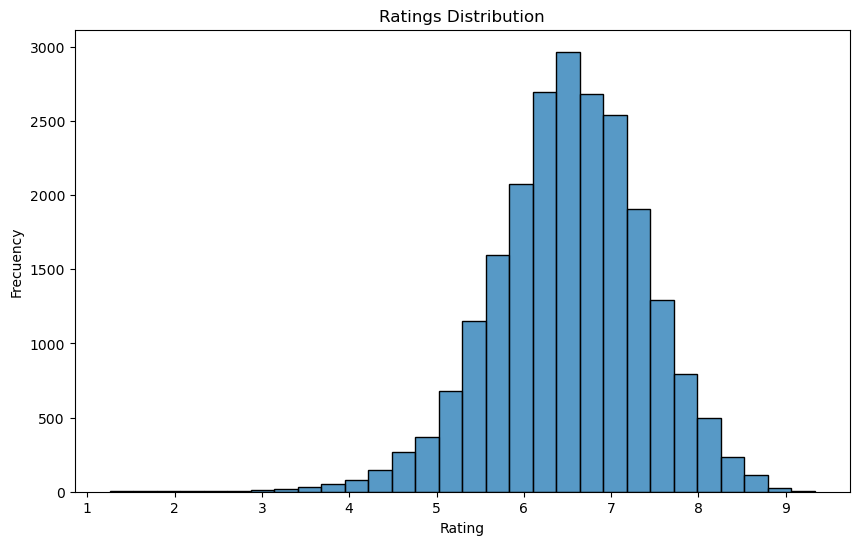

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(combined["average_rating"], bins=30)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frecuency")
plt.tight_layout
plt.show()

Number of players

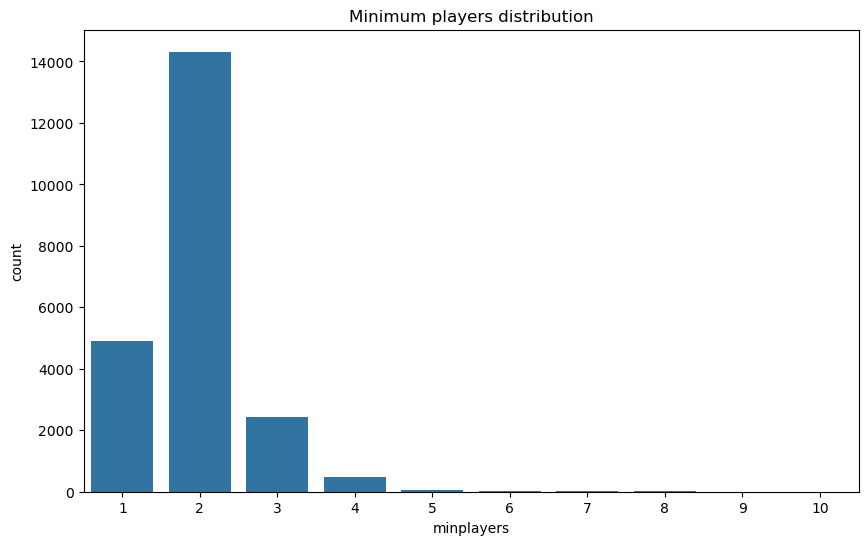

In [41]:
plt.figure(figsize=(10,6))

sns.countplot(x="minplayers", data=combined)

plt.title("Minimum players distribution")
plt.tight_layout
plt.show()

Game complexity

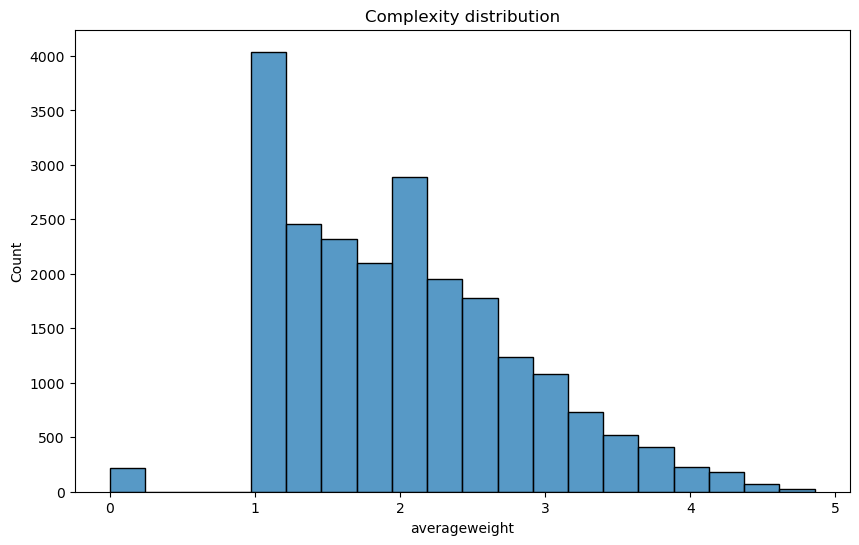

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(combined["averageweight"], bins=20)

plt.title("Complexity distribution")
plt.tight_layout
plt.show()

In [43]:
#We will have to work with these 0s in averageweight later

Complexity vs rating

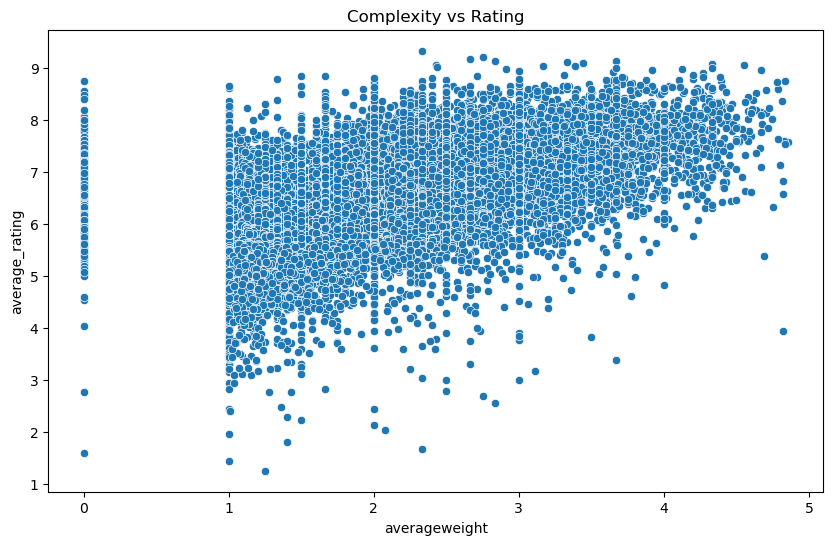

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="averageweight",y="average_rating",data=combined)

plt.title("Complexity vs Rating")
plt.tight_layout
plt.show()

Most popular games (by number of votes)

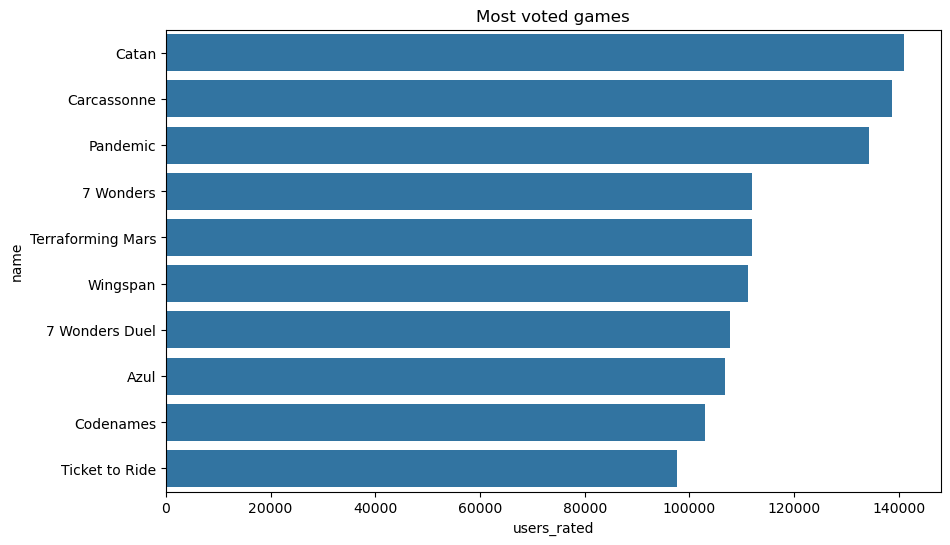

In [45]:
top_games = combined.sort_values("users_rated", ascending=False).head(10)
top_games[["name", "average_rating", "users_rated", "rank"]]

plt.figure(figsize=(10,6))

sns.barplot(y="name",x="users_rated",data=top_games)

plt.title("Most voted games")
plt.tight_layout
plt.show()

Now we can check if the most voted games (and therefore most played games) are the well posittioned on the ranking

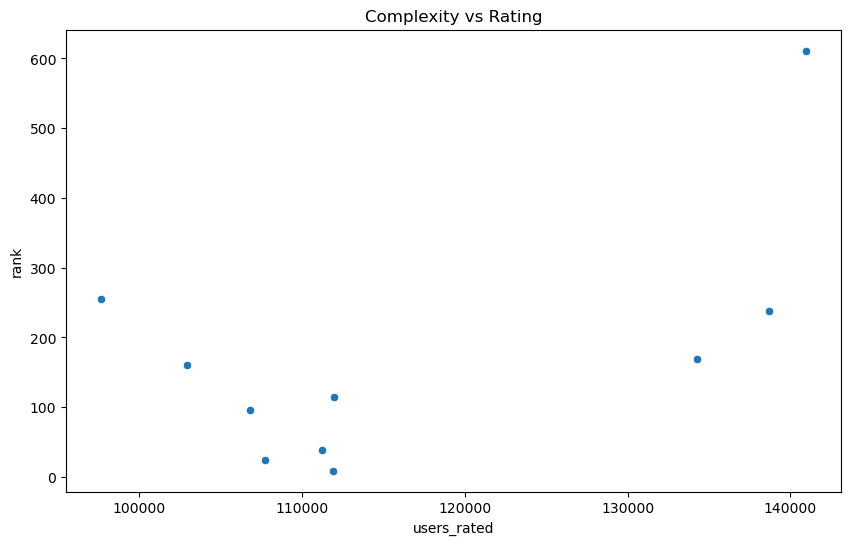

In [46]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="users_rated",y="rank",data=top_games)

plt.title("Complexity vs Rating")
plt.tight_layout
plt.show()

### Correlations

We will drop the columns related to the categories

In [47]:
analysis_df = combined.iloc[: , 0:14]
num_analysis_df = analysis_df.select_dtypes(include=np.number)

corr = num_analysis_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

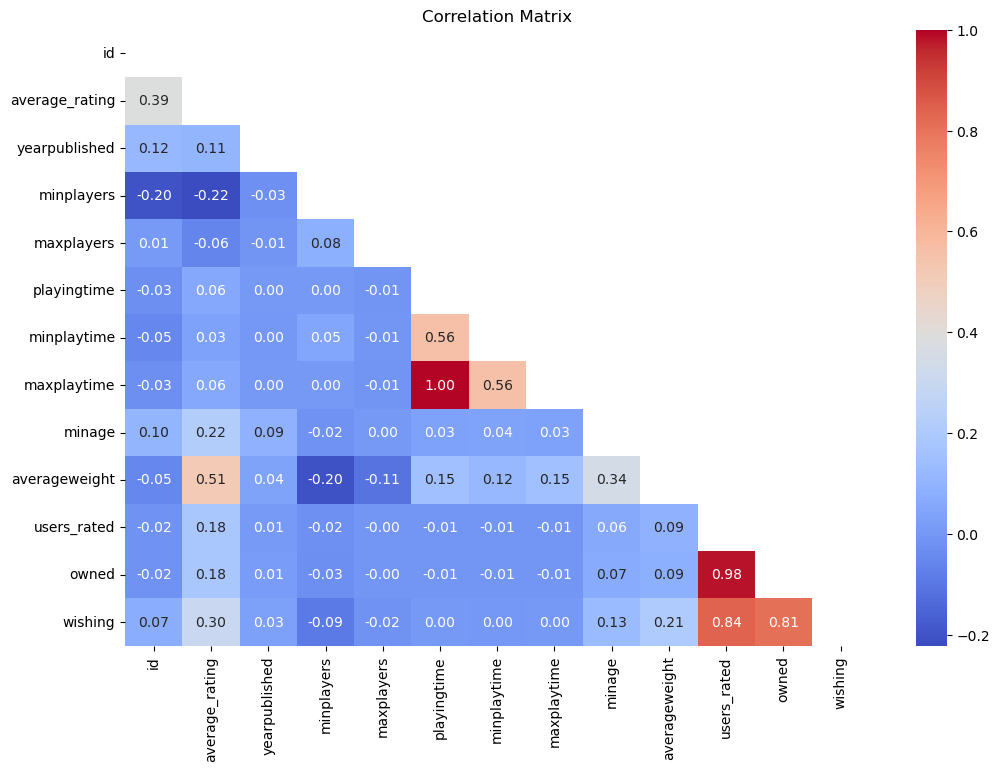

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",cmap='coolwarm')

plt.title("Correlation Matrix")
plt.tight_layout
plt.show()

# EDA Conclusions

Key findings:

- Ratings are concentrated between 6 and 8
- Most games are designed for **2-4 players**
- Most games have *low complexity*
- More complex games tend to have higher ratings
- Games with more reviews are not necessarily the highest-ranked

- The 'average playing' time coincides with the 'maximum playing time'
- Almost all votes are from people who own the game

In [49]:
df.to_csv("../data/processed/boardgames_clean.csv", index=False)